# 03 — All Stations PM2.5 Model

Prediction of daily PM2.5 concentrations across all Polish GIOŚ monitoring
stations using Open-Meteo meteorological data and station spatial features.

**Two evaluation scenarios:**
- **Scenario A — temporal split:** train 2016–2018, test 2019 (all stations in both sets).
  Answers: *how well does the model generalise to unseen time?*
- **Scenario B — spatial split:** random 80% of stations for training, remaining 20% for test.
  Answers: *how well does the model generalise to unseen stations?*

**Pipeline (both scenarios):**
1. Load `all_data.csv` produced by `01_data.ipynb`
2. Feature engineering — lag features (grouped by station), calendar encoding
3. `TimeSeriesSplit` + `RandomizedSearchCV` on training data
4. Final evaluation on held-out test set
5. Feature importance · per-station error analysis

**Models:** Random Forest · LightGBM · XGBoost  
**Target:** PM2.5 daily mean [µg/m³]

## 0. Imports & configuration

In [11]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform, loguniform

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Time split ────────────────────────────────────────────────────────────────
TRAIN_YEARS = [2016, 2017, 2018]
TEST_YEAR   = 2019

# ── Spatial split (Scenario B) ────────────────────────────────────────────────
TRAIN_STATION_FRAC = 0.8   # fraction of stations used for training

# ── Lag features (days) ───────────────────────────────────────────────────────
LAG_DAYS = [1, 2]

# ── Cross-validation ──────────────────────────────────────────────────────────
N_CV_SPLITS   = 5
N_ITER_SEARCH = 15 ##najlepiej 10 / 15, ale dla szybszych testów można 2-3 

RANDOM_STATE = 42

print("Configuration loaded.")
print(f"  Train years : {TRAIN_YEARS}")
print(f"  Test year   : {TEST_YEAR}")
print(f"  CV folds    : {N_CV_SPLITS} (TimeSeriesSplit)")
print(f"  Search iters: {N_ITER_SEARCH} per model")

Configuration loaded.
  Train years : [2016, 2017, 2018]
  Test year   : 2019
  CV folds    : 5 (TimeSeriesSplit)
  Search iters: 15 per model


## 1. Load data

In [12]:
df_raw = pd.read_csv("all_data.csv")
df_raw = df_raw.drop(columns=[c for c in df_raw.columns if "Unnamed" in c], errors="ignore")
df_raw["date"] = pd.to_datetime(df_raw["date"])

# Remove timezone info from date if present
if df_raw["date"].dt.tz is not None:
    df_raw["date"] = df_raw["date"].dt.tz_localize(None)

df_raw = df_raw.dropna(subset=["pm25"])
df_raw = df_raw.sort_values(["stacja", "date"]).reset_index(drop=True)

print(f"Loaded all_data.csv: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"  Stations  : {df_raw['stacja'].nunique()}")
print(f"  Date range: {df_raw['date'].min().date()} – {df_raw['date'].max().date()}")
print(f"  PM2.5     : mean={df_raw['pm25'].mean():.1f}  "
      f"median={df_raw['pm25'].median():.1f}  max={df_raw['pm25'].max():.1f} µg/m³")
df_raw.head()

Loaded all_data.csv: 63,230 rows × 21 columns
  Stations  : 45
  Date range: 2016-01-01 – 2019-12-31
  PM2.5     : mean=21.8  median=15.8  max=292.0 µg/m³


,date,stacja,pm25,temperature_2m_min,wind_speed_10m_max,wind_direction_10m_dominant,cloud_cover_mean,surface_pressure_mean,dew_point_2m_mean,relative_humidity_2m_min,...,boundary_layer_height,lat,lon,nearest_road_dist_m,total_road_length_km,building_count,elevation,population,built_up_volume,built_up_surface
0,2016-01-01,DsOsieczow21,19.0,0.1235,14.830076,263.91287,100.000000,1003.48140,0.008917,69.608590,...,243.75000,51.31763,15.431719,40.25876,148.95401,2334.0,179.0,2240.586464,859436.0,343715.0
1,2016-01-02,DsOsieczow21,48.5,-7.7765,23.933907,93.03884,83.250000,1001.29610,-8.189000,60.170800,...,360.62500,51.31763,15.431719,40.25876,148.95401,2334.0,179.0,2240.586464,859436.0,343715.0
2,2016-01-03,DsOsieczow21,54.9,-10.7765,18.806337,95.52572,53.916668,995.02716,-14.036918,59.579510,...,345.83334,51.31763,15.431719,40.25876,148.95401,2334.0,179.0,2240.586464,859436.0,343715.0
3,2016-01-04,DsOsieczow21,78.4,-9.0765,15.580141,112.42101,92.833336,977.57745,-11.630668,53.699577,...,402.08334,51.31763,15.431719,40.25876,148.95401,2334.0,179.0,2240.586464,859436.0,343715.0
4,2016-01-05,DsOsieczow21,79.5,-6.0765,12.015589,80.22388,96.791664,977.61650,-8.359835,70.941310,...,240.83333,51.31763,15.431719,40.25876,148.95401,2334.0,179.0,2240.586464,859436.0,343715.0


## 2. Exploratory data analysis

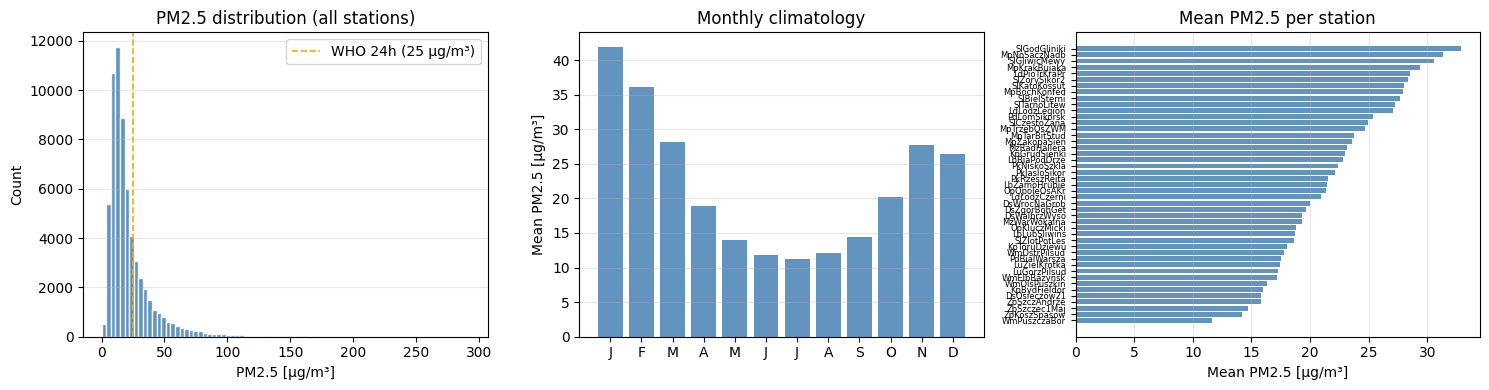

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# PM2.5 distribution
axes[0].hist(df_raw["pm25"], bins=80, color="steelblue", alpha=0.85, edgecolor="white")
axes[0].axvline(25, color="orange", linestyle="--", linewidth=1.2, label="WHO 24h (25 µg/m³)")
axes[0].set_xlabel("PM2.5 [µg/m³]")
axes[0].set_ylabel("Count")
axes[0].set_title("PM2.5 distribution (all stations)")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# Monthly climatology across all stations
monthly = df_raw.groupby(df_raw["date"].dt.month)["pm25"].mean()
axes[1].bar(monthly.index, monthly.values, color="steelblue", alpha=0.85)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
axes[1].set_ylabel("Mean PM2.5 [µg/m³]")
axes[1].set_title("Monthly climatology")
axes[1].grid(True, alpha=0.3, axis="y")

# Mean PM2.5 per station (sorted)
station_means = df_raw.groupby("stacja")["pm25"].mean().sort_values()
axes[2].barh(range(len(station_means)), station_means.values, color="steelblue", alpha=0.85)
axes[2].set_yticks(range(len(station_means)))
axes[2].set_yticklabels(station_means.index, fontsize=6)
axes[2].set_xlabel("Mean PM2.5 [µg/m³]")
axes[2].set_title("Mean PM2.5 per station")
axes[2].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("plot_01_eda.png", dpi=150, bbox_inches="tight")
plt.show()

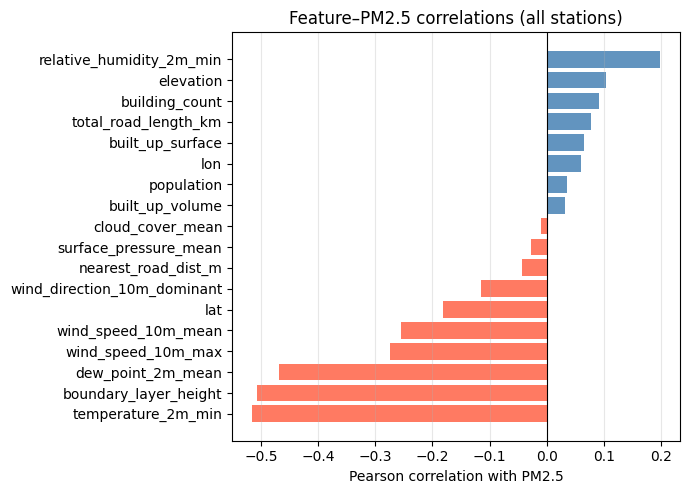

In [14]:
# Correlation matrix — weather and spatial features vs PM2.5
numeric_cols = df_raw.select_dtypes(include="number").columns.tolist()
corr_with_pm25 = (
    df_raw[numeric_cols]
    .corr()["pm25"]
    .drop("pm25")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(7, max(5, len(corr_with_pm25) * 0.28)))
colors = ["tomato" if v < 0 else "steelblue" for v in corr_with_pm25.values]
ax.barh(corr_with_pm25.index, corr_with_pm25.values, color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with PM2.5")
ax.set_title("Feature–PM2.5 correlations (all stations)")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("plot_02_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Feature engineering

Lag features are computed **within each station** using `groupby('stacja').shift()`
to avoid bleeding data across stations.

In [15]:
df = df_raw.copy()
df = df.set_index("date")

# Calendar features
df["month"]   = df.index.month
df["weekday"] = df.index.weekday
df["yearday"] = df.index.dayofyear

# Cyclic encoding
df["month_sin"]   = np.sin(2 * np.pi * df["month"]   / 12)
df["month_cos"]   = np.cos(2 * np.pi * df["month"]   / 12)
df["yearday_sin"] = np.sin(2 * np.pi * df["yearday"] / 365)
df["yearday_cos"] = np.cos(2 * np.pi * df["yearday"] / 365)

# Lag features — grouped by station to prevent cross-station leakage
LAG_FEATURES = [
    "temperature_2m_min",
    "wind_speed_10m_max",
    "wind_speed_10m_mean",
    "wind_direction_10m_dominant",
    "cloud_cover_mean",
    "surface_pressure_mean",
    "dew_point_2m_mean",
    "relative_humidity_2m_min",
    "boundary_layer_height",
]

for col in LAG_FEATURES:
    if col not in df.columns:
        continue
    for lag in LAG_DAYS:
        df[f"{col}_lag{lag}"] = df.groupby("stacja")[col].shift(lag)

# Drop rows where lags are NaN (first LAG_DAYS rows of each station)
lag_check_cols = [f"{col}_lag{max(LAG_DAYS)}"
                  for col in LAG_FEATURES if col in df.columns]
df = df.dropna(subset=lag_check_cols)

print(f"After feature engineering: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Define feature columns
NON_FEATURE_COLS = [
    "pm25", "stacja",
    "month", "weekday", "yearday",   # superseded by cyclic encoding
]
FEATURE_COLS = [c for c in df.columns if c not in NON_FEATURE_COLS]
print(f"Features: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

After feature engineering: 63,140 rows × 45 columns
Features: 40
['temperature_2m_min', 'wind_speed_10m_max', 'wind_direction_10m_dominant', 'cloud_cover_mean', 'surface_pressure_mean', 'dew_point_2m_mean', 'relative_humidity_2m_min', 'wind_speed_10m_mean', 'boundary_layer_height', 'lat', 'lon', 'nearest_road_dist_m', 'total_road_length_km', 'building_count', 'elevation', 'population', 'built_up_volume', 'built_up_surface', 'month_sin', 'month_cos', 'yearday_sin', 'yearday_cos', 'temperature_2m_min_lag1', 'temperature_2m_min_lag2', 'wind_speed_10m_max_lag1', 'wind_speed_10m_max_lag2', 'wind_speed_10m_mean_lag1', 'wind_speed_10m_mean_lag2', 'wind_direction_10m_dominant_lag1', 'wind_direction_10m_dominant_lag2', 'cloud_cover_mean_lag1', 'cloud_cover_mean_lag2', 'surface_pressure_mean_lag1', 'surface_pressure_mean_lag2', 'dew_point_2m_mean_lag1', 'dew_point_2m_mean_lag2', 'relative_humidity_2m_min_lag1', 'relative_humidity_2m_min_lag2', 'boundary_layer_height_lag1', 'boundary_layer_height

## 4. Scenario A — Temporal split (train 2016–2018, test 2019)

All stations appear in both train and test.  
Tests generalisation to **unseen time** (e.g. forecasting future years).

In [16]:
train_A = df[df.index.year.isin(TRAIN_YEARS)]
test_A  = df[df.index.year == TEST_YEAR]

# Sort by date for TimeSeriesSplit
train_A = train_A.sort_index()
test_A  = test_A.sort_index()

X_train_A = train_A[FEATURE_COLS]
y_train_A = train_A["pm25"]
X_test_A  = test_A[FEATURE_COLS]
y_test_A  = test_A["pm25"]

print("Scenario A — Temporal split")
print(f"  Train: {len(train_A):,} samples  "
      f"({train_A.index.min().date()} – {train_A.index.max().date()})  "
      f"{train_A['stacja'].nunique()} stations")
print(f"  Test : {len(test_A):,} samples  "
      f"({test_A.index.min().date()} – {test_A.index.max().date()})  "
      f"{test_A['stacja'].nunique()} stations")

Scenario A — Temporal split
  Train: 47,060 samples  (2016-01-03 – 2018-12-31)  45 stations
  Test : 16,080 samples  (2019-01-01 – 2019-12-31)  45 stations


## 5. Scenario B — Spatial split (train stations vs test stations)

80% of stations used for training (all years), remaining 20% held out entirely.  
Tests generalisation to **unseen locations** (e.g. predicting at new sites).

In [17]:
all_stations   = df["stacja"].unique()
rng            = np.random.default_rng(RANDOM_STATE)
n_train_st     = int(len(all_stations) * TRAIN_STATION_FRAC)
train_stations = rng.choice(all_stations, size=n_train_st, replace=False)
test_stations  = np.setdiff1d(all_stations, train_stations)

train_B = df[df["stacja"].isin(train_stations)].sort_index()
test_B  = df[df["stacja"].isin(test_stations)].sort_index()

X_train_B = train_B[FEATURE_COLS]
y_train_B = train_B["pm25"]
X_test_B  = test_B[FEATURE_COLS]
y_test_B  = test_B["pm25"]

print("Scenario B — Spatial split")
print(f"  Train: {len(train_B):,} samples  {len(train_stations)} stations")
print(f"  Test : {len(test_B):,} samples  {len(test_stations)} stations")
print(f"  Test stations: {sorted(test_stations)}")

Scenario B — Spatial split
  Train: 50,711 samples  36 stations
  Test : 12,429 samples  9 stations
  Test stations: ['KpBydFieldor', 'MzRadHallera', 'OpOpoleOsAKr', 'PdBialWarsza', 'PkRzeszRejta', 'SlKatoKossut', 'SlTarnoLitew', 'WmOstrPilsud', 'ZpSzczec1Maj']


## 6. Cross-validation strategy

`TimeSeriesSplit` applied to the **training set** of each scenario.  
Data is sorted by date so folds expand chronologically — no leakage.

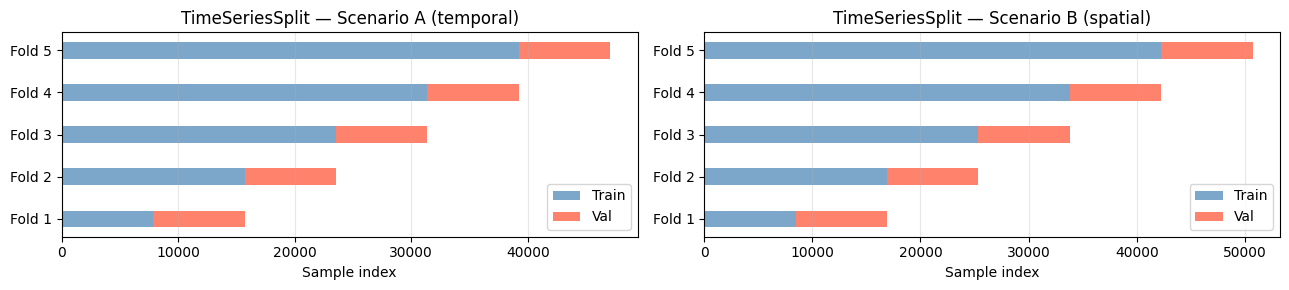

In [18]:
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

fig, axes = plt.subplots(1, 2, figsize=(13, 3))

for ax, (X_tr, label) in zip(axes, [
    (X_train_A, "Scenario A (temporal)"),
    (X_train_B, "Scenario B (spatial)"),
]):
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_tr)):
        ax.barh(fold, width=len(tr_idx),  left=0,           height=0.4,
                color="steelblue", alpha=0.7, label="Train" if fold == 0 else "")
        ax.barh(fold, width=len(val_idx), left=len(tr_idx), height=0.4,
                color="tomato",    alpha=0.8, label="Val"   if fold == 0 else "")
    ax.set_yticks(range(N_CV_SPLITS))
    ax.set_yticklabels([f"Fold {i+1}" for i in range(N_CV_SPLITS)])
    ax.set_xlabel("Sample index")
    ax.set_title(f"TimeSeriesSplit — {label}")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("plot_03_cv_folds.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Model definitions

Each model wrapped in a `Pipeline(StandardScaler → model)`.  
Hyperparameters tuned via `RandomizedSearchCV` with `TimeSeriesSplit`.

In [ ]:
def make_searches() -> dict:
    """
    Return a dict of {model_name: RandomizedSearchCV} objects.
    Called once per scenario so each scenario gets a fresh search.
    """
    configs = {
        "Random Forest": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model",  RandomForestRegressor(
                    random_state=RANDOM_STATE, n_jobs=-1)),
            ]),
            {
                "model__n_estimators":      randint(100, 300),
                "model__max_depth":         [None, 10, 20, 30],
                "model__min_samples_split": randint(2, 20),
                "model__min_samples_leaf":  randint(1, 10),
                "model__max_features":      ["sqrt", "log2", 0.5, 0.7],
            },
        ),
        "LightGBM": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model",  lgb.LGBMRegressor(
                    random_state=RANDOM_STATE, verbose=-1)),
            ]),
            {
                "model__n_estimators":      randint(100, 300), #powinno być 600 najlepiej
                "model__max_depth":         randint(3, 12),
                "model__learning_rate":     loguniform(0.01, 0.3),
                "model__num_leaves":        randint(15, 127),
                "model__min_child_samples": randint(5, 50),
                "model__subsample":         uniform(0.6, 0.4),
                "model__colsample_bytree":  uniform(0.6, 0.4),
                "model__reg_alpha":         loguniform(1e-3, 10),
                "model__reg_lambda":        loguniform(1e-3, 10),
            },
        ),
        "XGBoost": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model",  xgb.XGBRegressor(
                    random_state=RANDOM_STATE,
                    tree_method="hist",
                    verbosity=0,
                )),
            ]),
            {
                "model__n_estimators":     randint(100, 300), 
                "model__max_depth":        randint(3, 10),
                "model__learning_rate":    loguniform(0.01, 0.3),
                "model__subsample":        uniform(0.6, 0.4),
                "model__colsample_bytree": uniform(0.6, 0.4),
                "model__reg_alpha":        loguniform(1e-3, 10),
                "model__reg_lambda":       loguniform(1e-3, 10),
                "model__min_child_weight": randint(1, 10),
            },
        ),
    }

    searches = {}
    for name, (pipeline, param_dist) in configs.items():
        searches[name] = RandomizedSearchCV(
            estimator           = pipeline,
            param_distributions = param_dist,
            n_iter              = N_ITER_SEARCH,
            cv                  = tscv,
            scoring             = "neg_root_mean_squared_error",
            n_jobs              = -1,
            random_state        = RANDOM_STATE,
            verbose             = 1,
            refit               = True,
        )
    return searches


def evaluate(name: str, estimator, X_test, y_test) -> dict:
    """Return test-set metrics as a dict."""
    y_pred = estimator.predict(X_test)
    return {
        "model":  name,
        "RMSE":   np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE":    mean_absolute_error(y_test, y_pred),
        "R2":     r2_score(y_test, y_pred),
        "Bias":   float(np.mean(y_pred - y_test)),
        "y_pred": y_pred,
    }


print("Model factory ready.")

Model factory ready.


## 8. Scenario A — Training & evaluation (temporal split)

In [20]:
print("=" * 55)
print("SCENARIO A — Temporal split (train 2016–2018, test 2019)")
print("=" * 55)

searches_A = make_searches()
results_A  = []

for name, search in searches_A.items():
    print(f"\nFitting {name}...")
    search.fit(X_train_A, y_train_A)
    print(f"  Best CV RMSE : {-search.best_score_:.3f} µg/m³")
    res = evaluate(name, search.best_estimator_, X_test_A, y_test_A)
    results_A.append(res)
    print(f"  Test RMSE    : {res['RMSE']:.3f} µg/m³  "
          f"R²={res['R2']:.3f}  Bias={res['Bias']:+.3f}")

df_metrics_A = (
    pd.DataFrame(results_A)
    .set_index("model")
    .drop(columns="y_pred")
)
print("\nScenario A — Test metrics:")
print(df_metrics_A.round(3).to_string())

SCENARIO A — Temporal split (train 2016–2018, test 2019)

Fitting Random Forest...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
  Best CV RMSE : 11.909 µg/m³
  Test RMSE    : 9.091 µg/m³  R²=0.628  Bias=+2.128

Fitting LightGBM...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
  Best CV RMSE : 11.022 µg/m³
  Test RMSE    : 8.622 µg/m³  R²=0.665  Bias=+2.059

Fitting XGBoost...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
  Best CV RMSE : 11.198 µg/m³
  Test RMSE    : 8.580 µg/m³  R²=0.669  Bias=+2.136

Scenario A — Test metrics:
                RMSE    MAE     R2   Bias
model                                    
Random Forest  9.091  5.927  0.628  2.128
LightGBM       8.622  5.717  0.665  2.059
XGBoost        8.580  5.635  0.669  2.136


## 9. Scenario B — Training & evaluation (spatial split)

In [21]:
print("=" * 55)
print("SCENARIO B — Spatial split (train/test by station)")
print("=" * 55)

searches_B = make_searches()
results_B  = []

for name, search in searches_B.items():
    print(f"\nFitting {name}...")
    search.fit(X_train_B, y_train_B)
    print(f"  Best CV RMSE : {-search.best_score_:.3f} µg/m³")
    res = evaluate(name, search.best_estimator_, X_test_B, y_test_B)
    results_B.append(res)
    print(f"  Test RMSE    : {res['RMSE']:.3f} µg/m³  "
          f"R²={res['R2']:.3f}  Bias={res['Bias']:+.3f}")

df_metrics_B = (
    pd.DataFrame(results_B)
    .set_index("model")
    .drop(columns="y_pred")
)
print("\nScenario B — Test metrics:")
print(df_metrics_B.round(3).to_string())

SCENARIO B — Spatial split (train/test by station)

Fitting Random Forest...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
  Best CV RMSE : 11.348 µg/m³
  Test RMSE    : 8.351 µg/m³  R²=0.788  Bias=+0.323

Fitting LightGBM...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
  Best CV RMSE : 10.621 µg/m³
  Test RMSE    : 8.432 µg/m³  R²=0.784  Bias=-0.120

Fitting XGBoost...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
  Best CV RMSE : 10.687 µg/m³
  Test RMSE    : 8.045 µg/m³  R²=0.803  Bias=+0.083

Scenario B — Test metrics:
                RMSE    MAE     R2   Bias
model                                    
Random Forest  8.351  5.019  0.788  0.323
LightGBM       8.432  5.350  0.784 -0.120
XGBoost        8.045  5.002  0.803  0.083


## 10. Evaluation plots — Scenario A

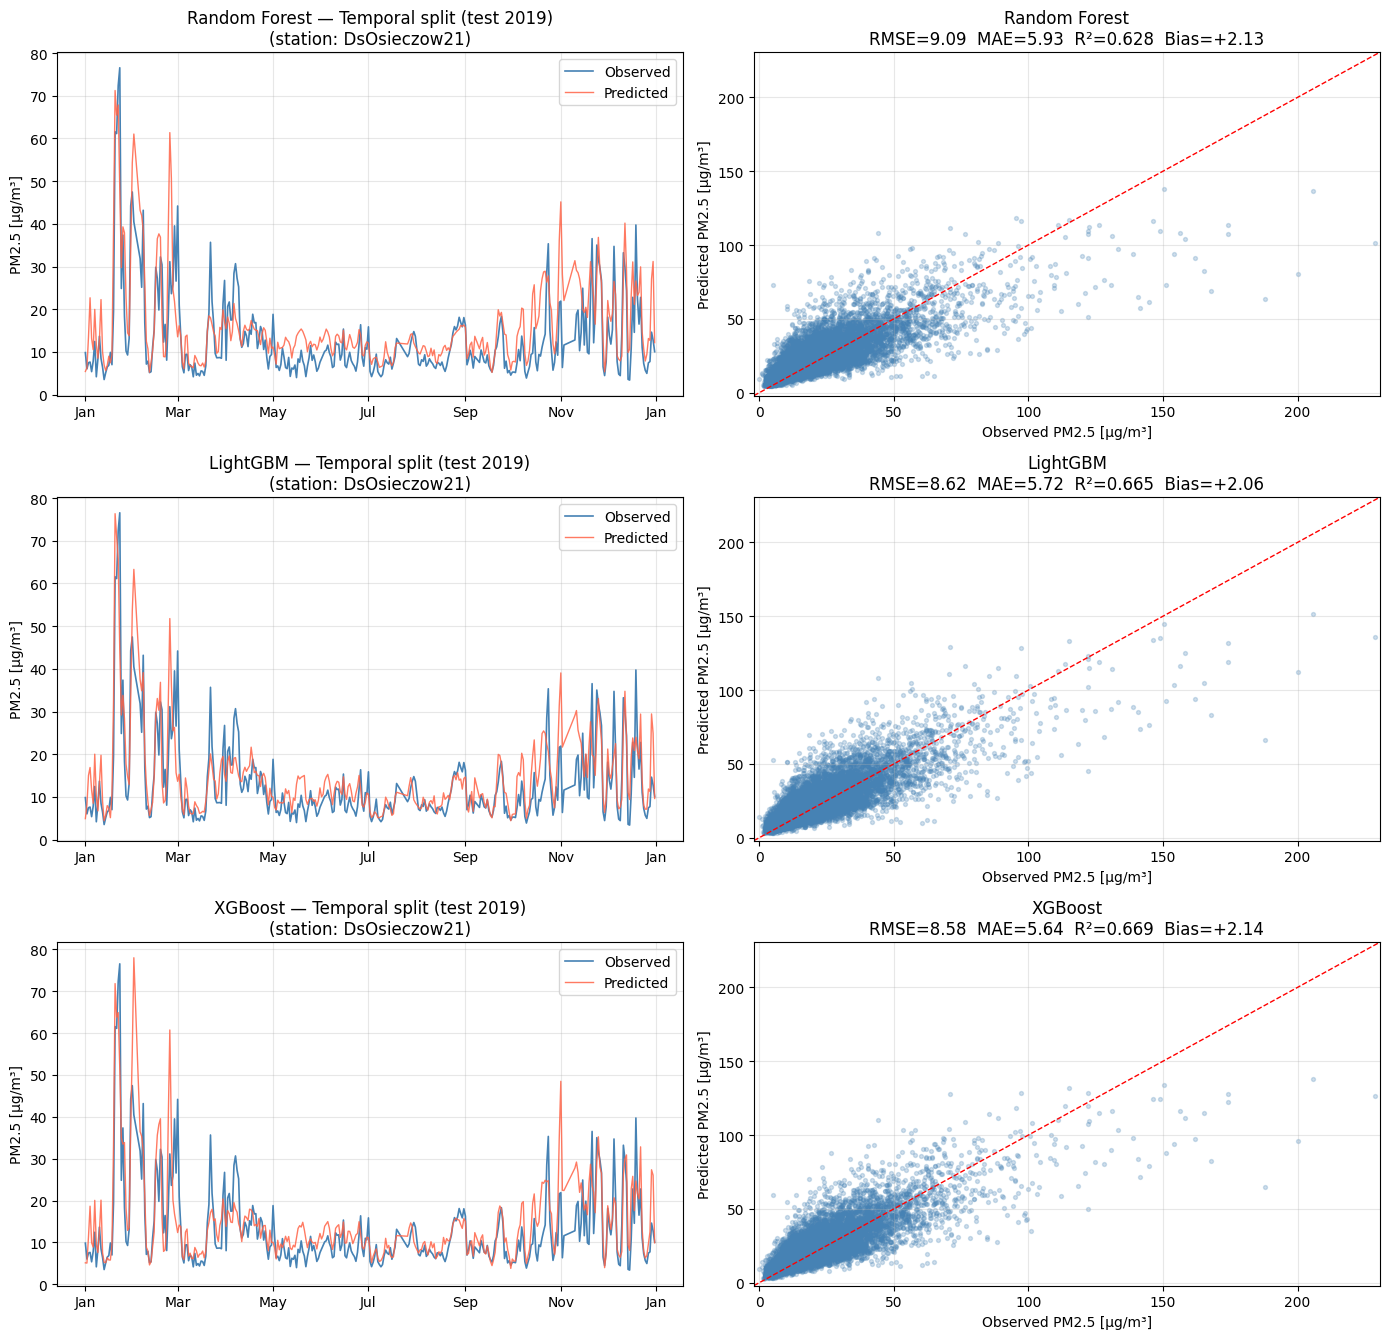

Saved plot_04A_evaluation.png


In [22]:
def plot_evaluation(results: list, y_test: pd.Series, test_df: pd.DataFrame,
                    title_suffix: str, save_prefix: str) -> None:
    """Scatter + time series plots for all models in results."""
    n = len(results)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4.5 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for row, res in enumerate(results):
        y_pred = res["y_pred"]
        name   = res["model"]

        # Time series (first station as example)
        ax = axes[row, 0]
        example_st = test_df["stacja"].iloc[0]
        mask = test_df["stacja"] == example_st
        ax.plot(test_df.index[mask], y_test.values[mask],
                label="Observed", linewidth=1.2, color="steelblue")
        ax.plot(test_df.index[mask], y_pred[mask],
                label="Predicted", linewidth=1.0, color="tomato", alpha=0.85)
        ax.set_title(f"{name} — {title_suffix}\n(station: {example_st})")
        ax.set_ylabel("PM2.5 [µg/m³]")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

        # Scatter
        ax = axes[row, 1]
        lim = [min(y_test.min(), y_pred.min()) - 2,
               max(y_test.max(), y_pred.max()) + 2]
        ax.scatter(y_test, y_pred, alpha=0.25, s=8, color="steelblue",
                   rasterized=True)
        ax.plot(lim, lim, "r--", linewidth=1)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel("Observed PM2.5 [µg/m³]")
        ax.set_ylabel("Predicted PM2.5 [µg/m³]")
        ax.set_title(
            f"{name}\n"
            f"RMSE={res['RMSE']:.2f}  MAE={res['MAE']:.2f}  "
            f"R²={res['R2']:.3f}  Bias={res['Bias']:+.2f}"
        )
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    path = f"{save_prefix}_evaluation.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")


plot_evaluation(results_A, y_test_A, test_A,
                title_suffix="Temporal split (test 2019)",
                save_prefix="plot_04A")

## 11. Evaluation plots — Scenario B

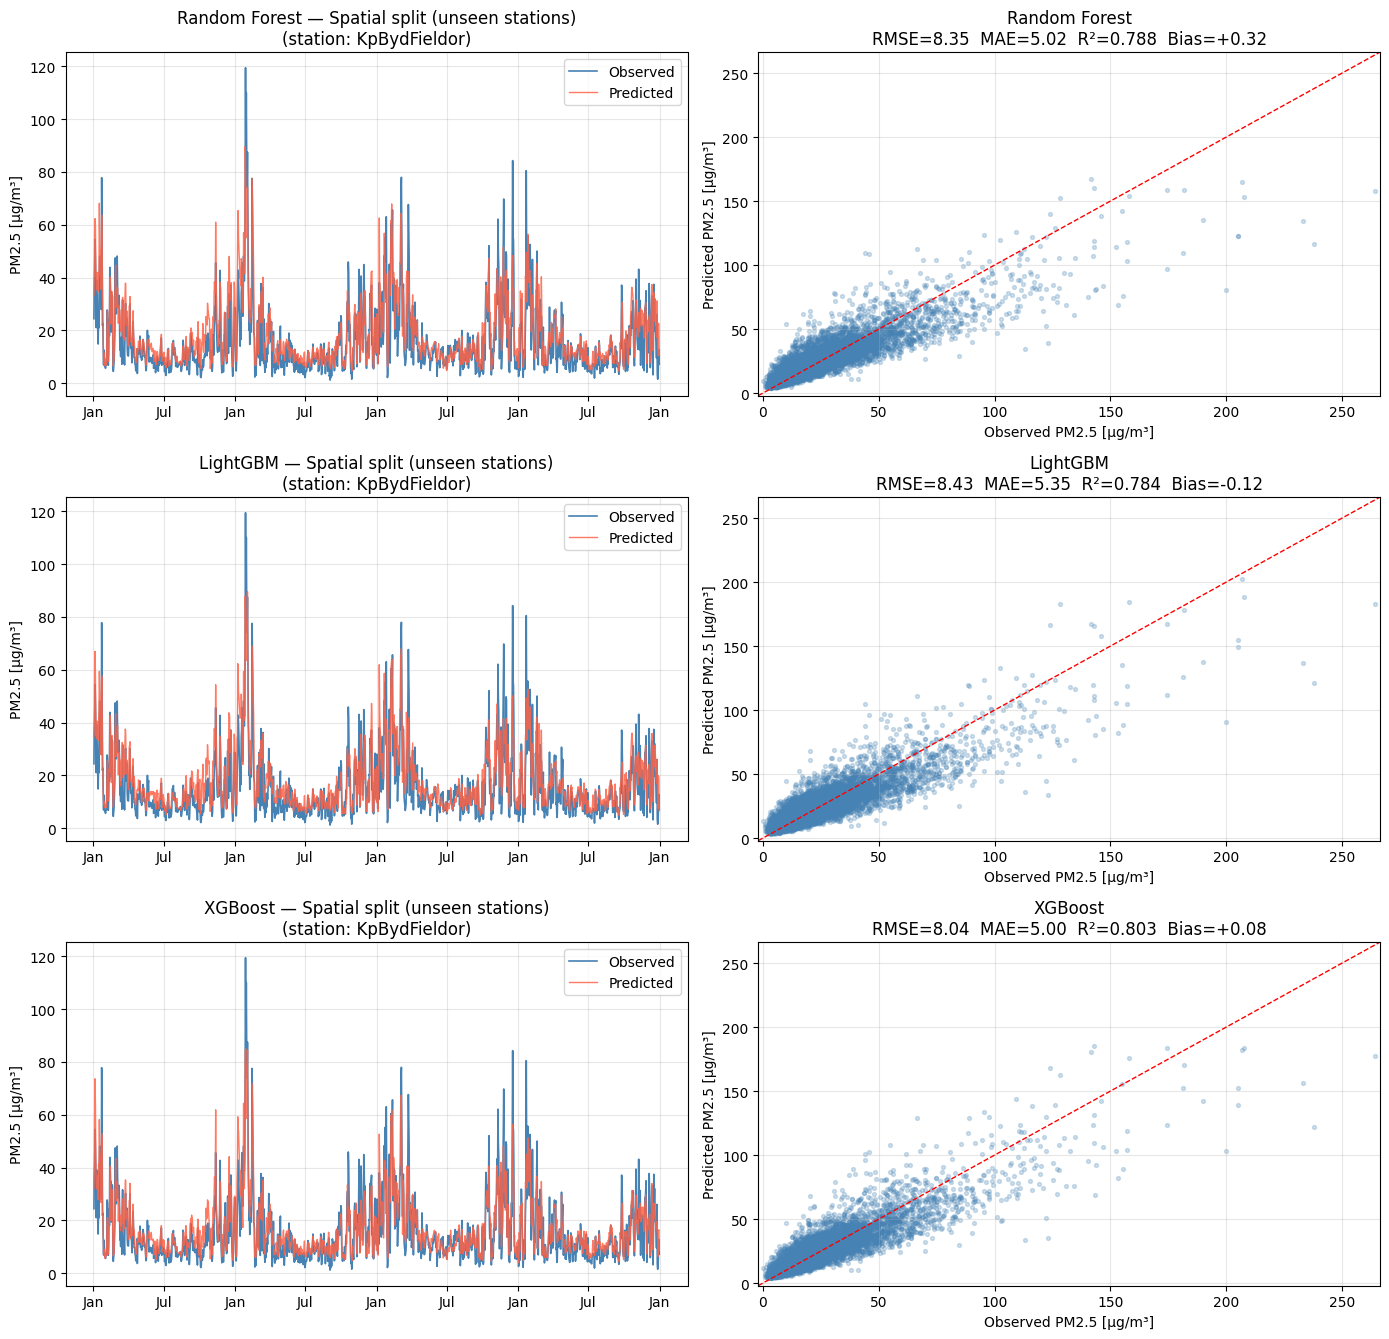

Saved plot_04B_evaluation.png


In [23]:
plot_evaluation(results_B, y_test_B, test_B,
                title_suffix="Spatial split (unseen stations)",
                save_prefix="plot_04B")

## 12. Metrics comparison — A vs B

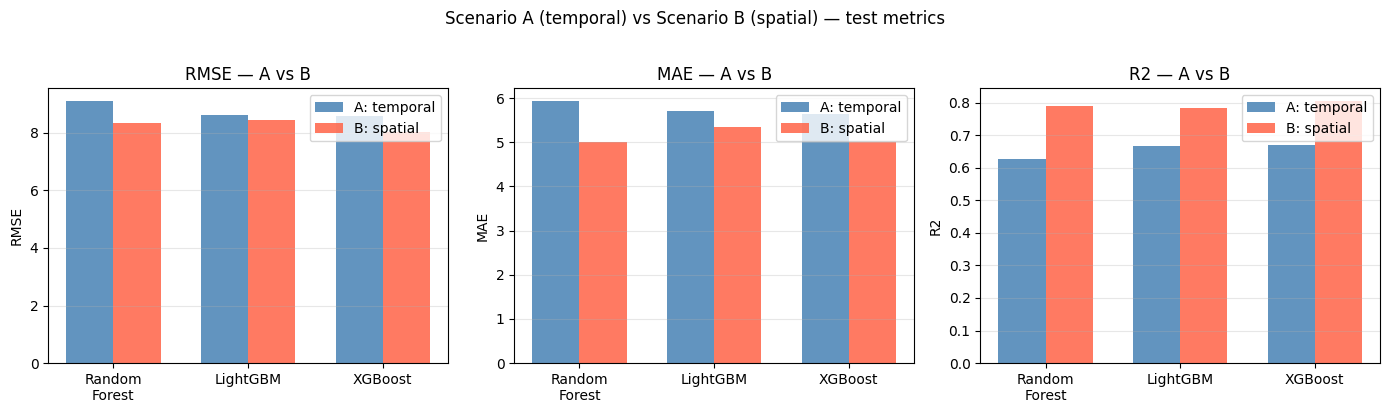

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics   = ["RMSE", "MAE", "R2"]
x         = np.arange(len(searches_A))
width     = 0.35
model_names = list(searches_A.keys())

for ax, metric in zip(axes, metrics):
    vals_A = [df_metrics_A.loc[m, metric] for m in model_names]
    vals_B = [df_metrics_B.loc[m, metric] for m in model_names]
    ax.bar(x - width/2, vals_A, width, label="A: temporal", color="steelblue", alpha=0.85)
    ax.bar(x + width/2, vals_B, width, label="B: spatial",  color="tomato",    alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(" ", "\n") for m in model_names])
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} — A vs B")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Scenario A (temporal) vs Scenario B (spatial) — test metrics",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("plot_05_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Feature importance

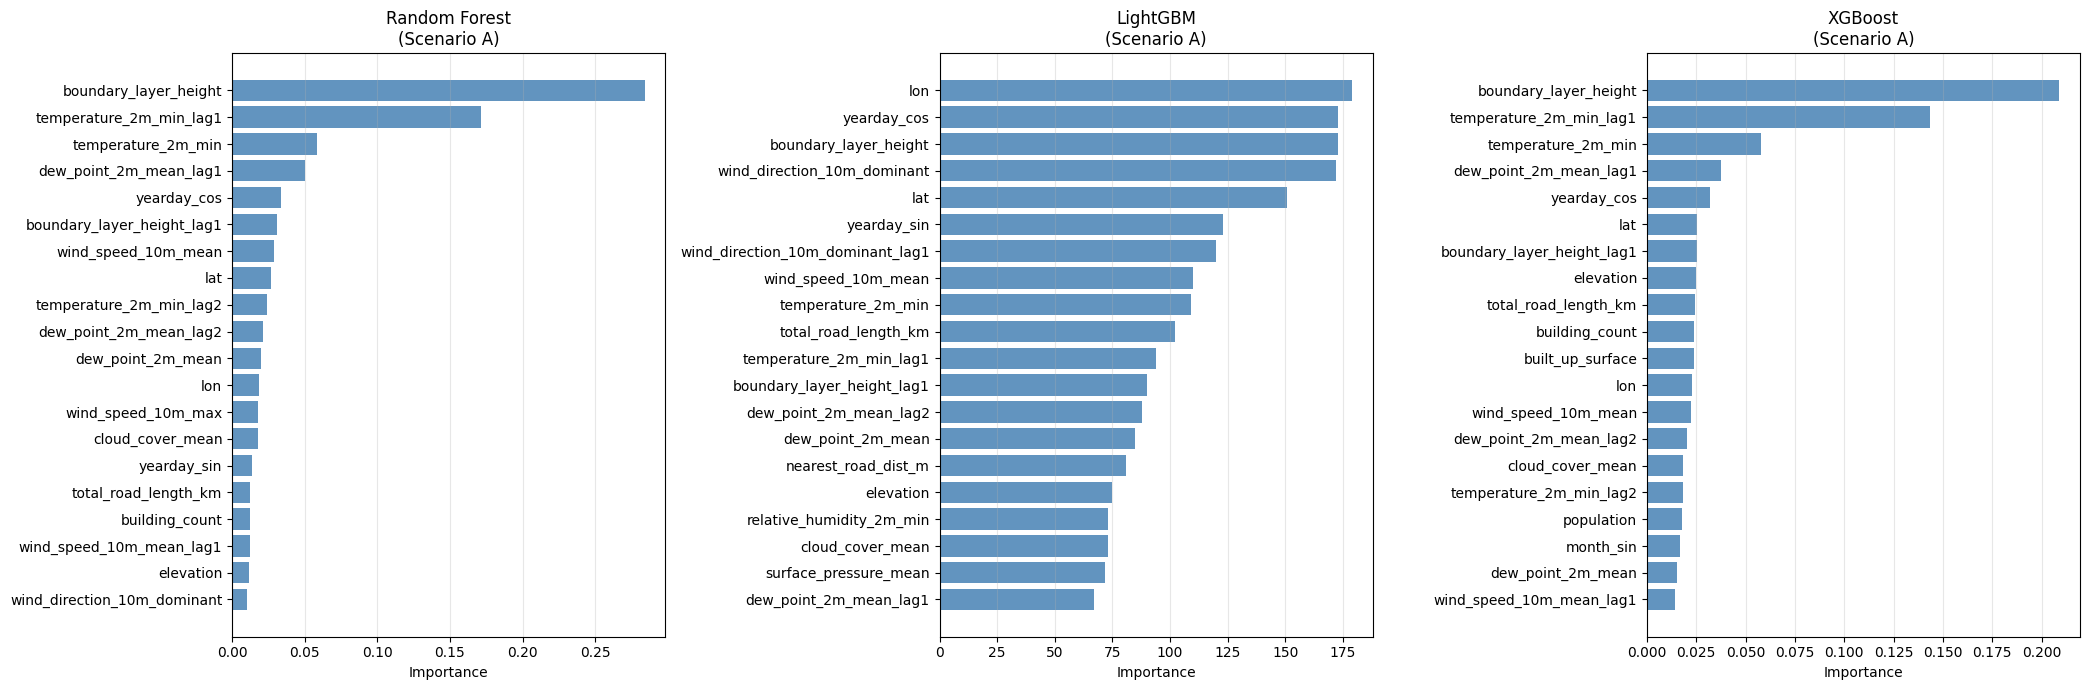

Saved plot_06A_feature_importance.png


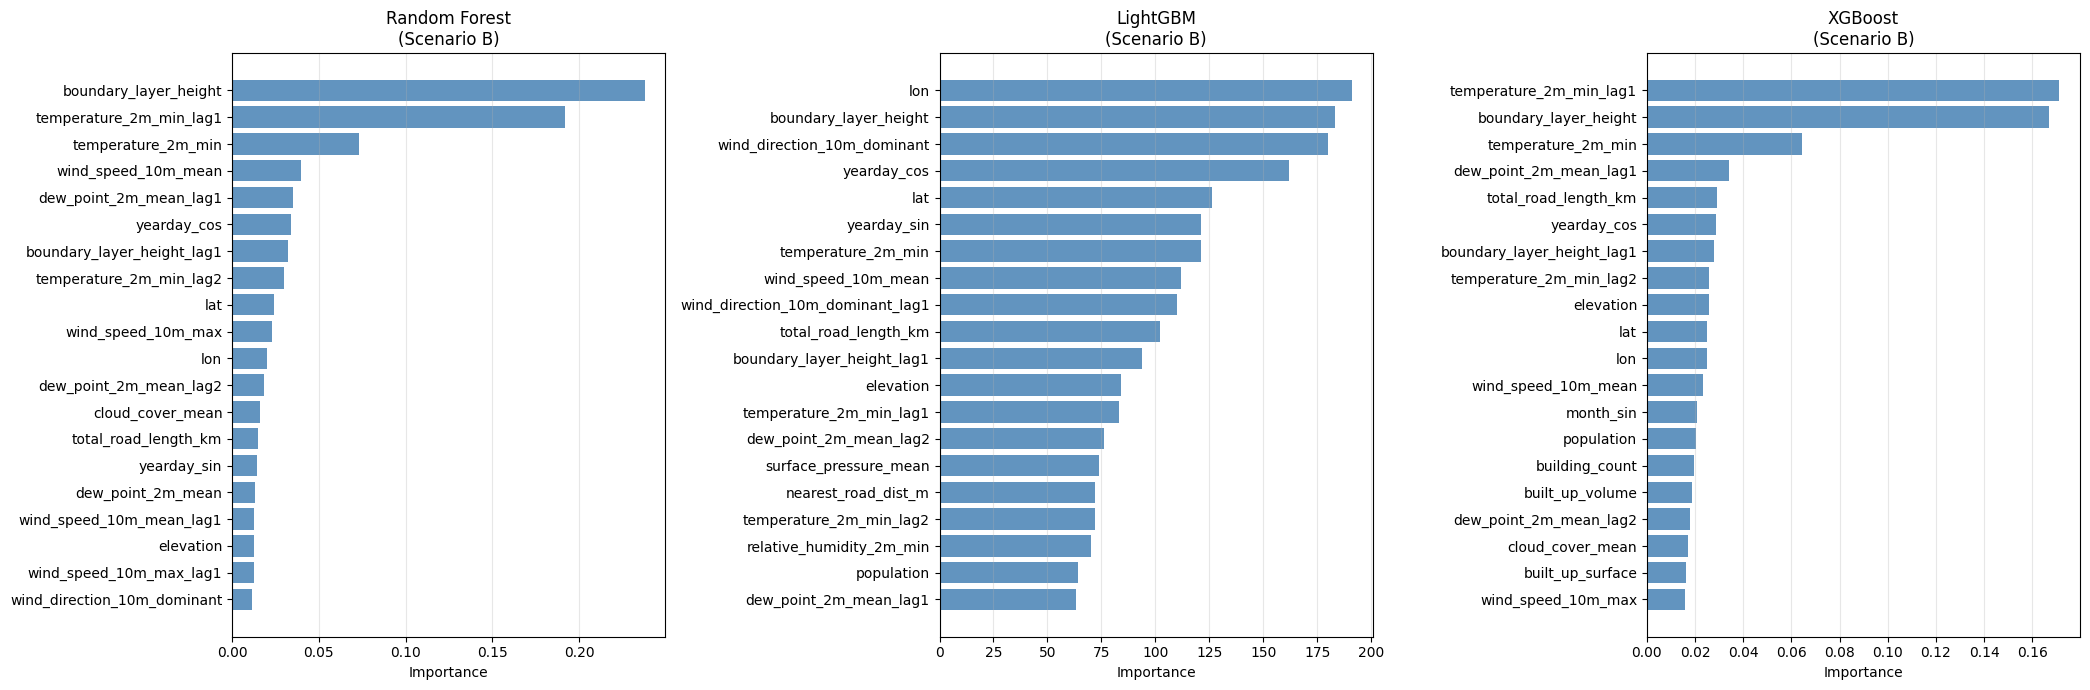

Saved plot_06B_feature_importance.png


In [25]:
def plot_feature_importance(searches: dict, scenario_label: str,
                            feature_names: list, save_path: str,
                            top_n: int = 20) -> None:
    """Top-N feature importances for all models in a scenario."""
    n = len(searches)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
    if n == 1:
        axes = [axes]

    for ax, (name, search) in zip(axes, searches.items()):
        model_step   = search.best_estimator_.named_steps["model"]
        importances  = model_step.feature_importances_
        idx          = np.argsort(importances)[-top_n:]
        ax.barh(
            np.array(feature_names)[idx],
            importances[idx],
            color="steelblue", alpha=0.85,
        )
        ax.set_xlabel("Importance")
        ax.set_title(f"{name}\n({scenario_label})")
        ax.grid(True, alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {save_path}")


plot_feature_importance(
    searches_A, "Scenario A", FEATURE_COLS,
    "plot_06A_feature_importance.png"
)
plot_feature_importance(
    searches_B, "Scenario B", FEATURE_COLS,
    "plot_06B_feature_importance.png"
)

## 14. Per-station error analysis (Scenario A)

For each station in the test set, compute RMSE and bias  
for the best-performing model.

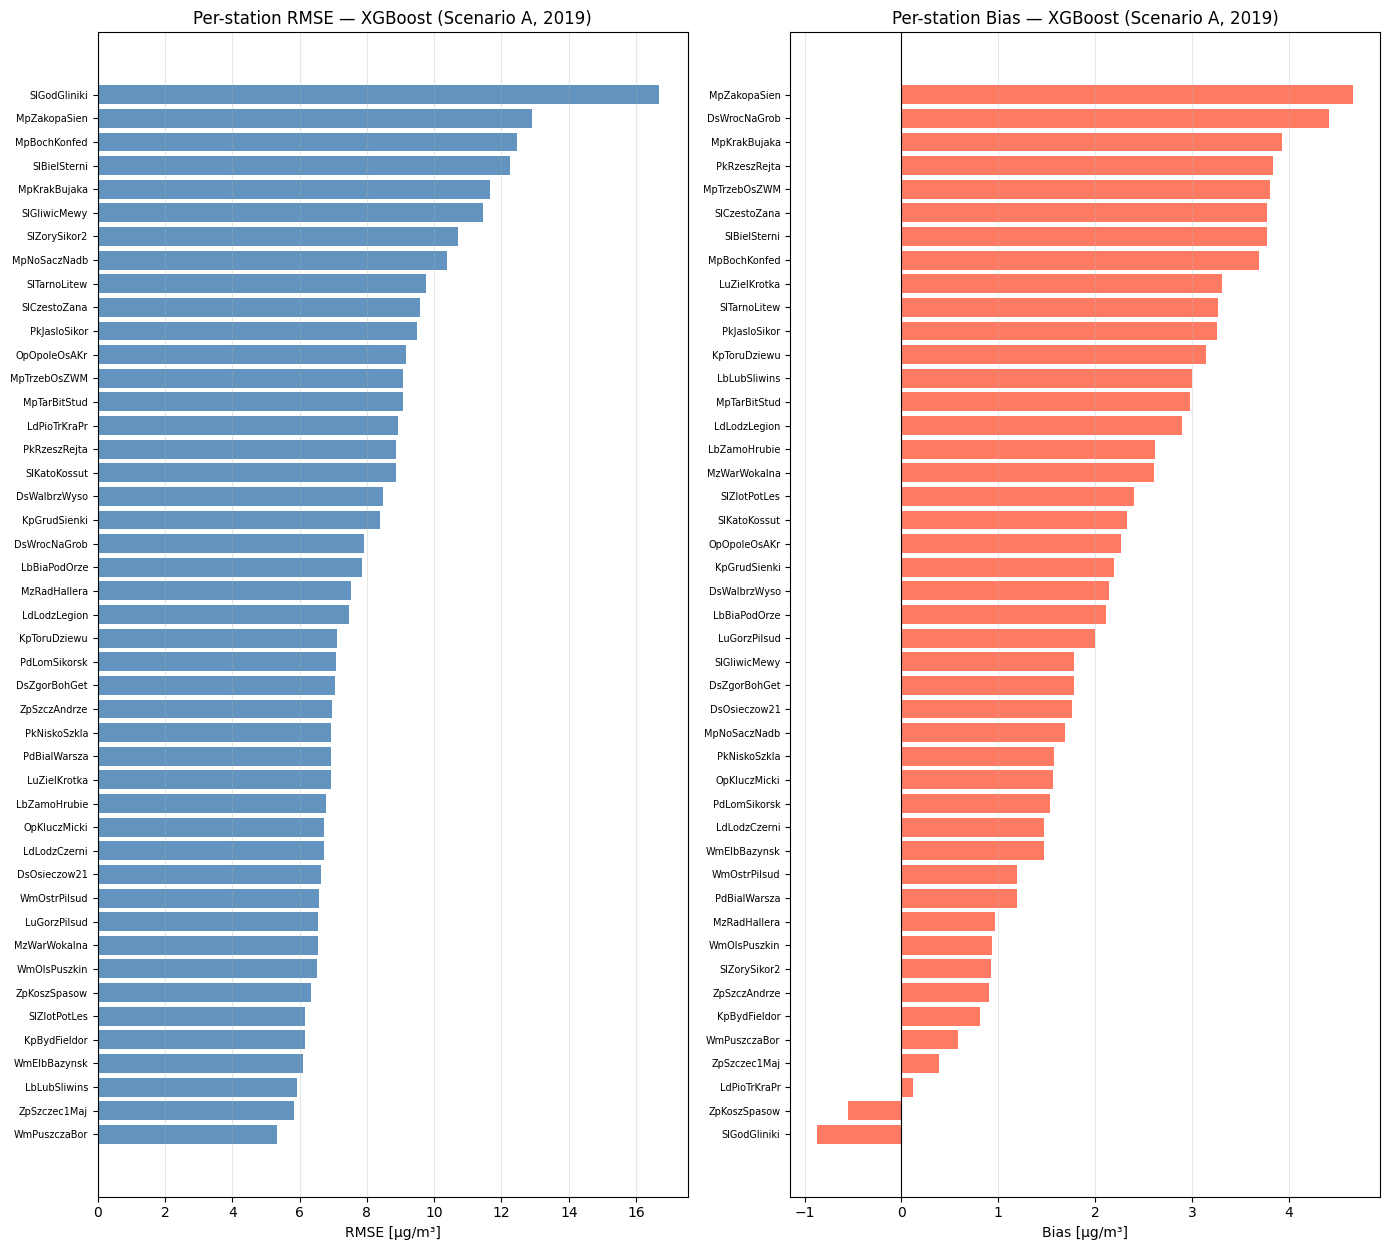


Per-station metrics — XGBoost (Scenario A):
      stacja   n  RMSE  MAE   R2  Bias  mean_pm25
WmPuszczaBor 361  5.34 3.79 0.54  0.59      11.10
ZpSzczec1Maj 342  5.84 3.92 0.55  0.39      12.75
LbLubSliwins 365  5.92 4.50 0.67  3.01      15.99
WmElbBazynsk 352  6.11 4.22 0.60  1.47      15.05
KpBydFieldor 365  6.15 4.17 0.66  0.81      14.55
SlZlotPotLes 357  6.17 4.50 0.58  2.41      16.08
ZpKoszSpasow 365  6.35 4.04 0.54 -0.55      13.67
WmOlsPuszkin 355  6.52 4.42 0.55  0.93      14.98
MzWarWokalna 365  6.55 4.88 0.52  2.61      15.67
LuGorzPilsud 356  6.56 4.45 0.49  2.00      14.78
WmOstrPilsud 357  6.57 4.42 0.57  1.19      15.65
DsOsieczow21 347  6.65 4.31 0.58  1.76      13.10
LdLodzCzerni 361  6.73 4.69 0.61  1.47      18.62
OpKluczMicki 360  6.74 4.75 0.71  1.57      17.28
LbZamoHrubie 363  6.79 5.13 0.70  2.62      18.40
LuZielKrotka 365  6.92 4.87 0.42  3.32      13.86
PdBialWarsza 347  6.94 4.92 0.45  1.19      15.78
PkNiskoSzkla 363  6.95 4.89 0.74  1.57      20.34
ZpSzc

In [26]:
# Use best model from Scenario A (lowest RMSE)
best_name_A = df_metrics_A["RMSE"].idxmin()
best_pred_A = next(r["y_pred"] for r in results_A if r["model"] == best_name_A)

station_metrics = []
for st in test_A["stacja"].unique():
    mask   = test_A["stacja"] == st
    yt     = y_test_A.values[mask]
    yp     = best_pred_A[mask]
    if len(yt) < 5:
        continue
    station_metrics.append({
        "stacja": st,
        "n":      len(yt),
        "RMSE":   np.sqrt(mean_squared_error(yt, yp)),
        "MAE":    mean_absolute_error(yt, yp),
        "R2":     r2_score(yt, yp),
        "Bias":   float(np.mean(yp - yt)),
        "mean_pm25": float(np.mean(yt)),
    })

df_station = pd.DataFrame(station_metrics).sort_values("RMSE")

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(df_station) * 0.28)))

for ax, metric, color in zip(axes, ["RMSE", "Bias"], ["steelblue", "tomato"]):
    sorted_df = df_station.sort_values(metric)
    bars = ax.barh(sorted_df["stacja"], sorted_df[metric],
                   color=color, alpha=0.85)
    if metric == "Bias":
        ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(f"{metric} [µg/m³]")
    ax.set_title(f"Per-station {metric} — {best_name_A} (Scenario A, 2019)")
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("plot_07_per_station_errors.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPer-station metrics — {best_name_A} (Scenario A):")
print(df_station.round(2).to_string(index=False))

## 15. Summary

In [27]:
best_name_B = df_metrics_B["RMSE"].idxmin()

print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Stations total : {df['stacja'].nunique()}")
print(f"Features       : {len(FEATURE_COLS)}")
print(f"CV strategy    : TimeSeriesSplit, {N_CV_SPLITS} folds")
print(f"Search iters   : {N_ITER_SEARCH} per model")
print()
print("── Scenario A (temporal split, test 2019) ──")
print(df_metrics_A.round(3).to_string())
print(f"Best model: {best_name_A}")
print()
print("── Scenario B (spatial split, unseen stations) ──")
print(df_metrics_B.round(3).to_string())
print(f"Best model: {best_name_B}")
print()
print("Saved plots:")
for p in [
    "plot_01_eda.png",
    "plot_02_correlations.png",
    "plot_03_cv_folds.png",
    "plot_04A_evaluation.png",
    "plot_04B_evaluation.png",
    "plot_05_metrics_comparison.png",
    "plot_06A_feature_importance.png",
    "plot_06B_feature_importance.png",
    "plot_07_per_station_errors.png",
]:
    print(f"  {p}")

SUMMARY
Stations total : 45
Features       : 40
CV strategy    : TimeSeriesSplit, 5 folds
Search iters   : 15 per model

── Scenario A (temporal split, test 2019) ──
                RMSE    MAE     R2   Bias
model                                    
Random Forest  9.091  5.927  0.628  2.128
LightGBM       8.622  5.717  0.665  2.059
XGBoost        8.580  5.635  0.669  2.136
Best model: XGBoost

── Scenario B (spatial split, unseen stations) ──
                RMSE    MAE     R2   Bias
model                                    
Random Forest  8.351  5.019  0.788  0.323
LightGBM       8.432  5.350  0.784 -0.120
XGBoost        8.045  5.002  0.803  0.083
Best model: XGBoost

Saved plots:
  plot_01_eda.png
  plot_02_correlations.png
  plot_03_cv_folds.png
  plot_04A_evaluation.png
  plot_04B_evaluation.png
  plot_05_metrics_comparison.png
  plot_06A_feature_importance.png
  plot_06B_feature_importance.png
  plot_07_per_station_errors.png
